# (노트) Boxplot, Histogram
> 완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [파이썬]

### About this doc 

`-` 데이터시각화 강의 드래프트

### import

In [8]:
import matplotlib.pyplot as plt 
import numpy as np

### boxplot 

`-` ref: https://matplotlib.org/3.1.1/gallery/pyplots/boxplot_demo_pyplot.html#sphx-glr-gallery-pyplots-boxplot-demo-pyplot-py

#### 전북고예제: 평균은 괜찮은 측정값인가? (통계학과)

`-` 전북고등학교에서 통계학을 수업하는 두 선생님이 있다. 편의상 A 선생님과 B 선생님이라고 하자. A 선생님이 강의한 반의 통계학 점수는 평균 79.1점, B 선생님이 강의한 반의 통계학 점수는 평균 78.3점 이라고 하자. 

`-` 의사결정: A 선생님에게 배운 학생들의 실력이 평균적으로 좋을것이다.

In [9]:
y1=[75,75,76,76,77,77,79,79,79,98] ## A 선생님에게 통계학을 배운 학생의 점수들
y2=[76,76,77,77,78,78,80,80,80,81] ## B 선생님에게 통계학을 배운 학생의 점수들 

In [10]:
np.mean(y1), np.mean(y2)

(79.1, 78.3)

`-` 평균은 A반(=A선생님에게 통계학을 배운 반)이 더 높다. 그런데 98점을 받은 학생때문에 전체 평균이 올라간것이지 나머지 학생들은 모두 B반(=B선생님에게 통계학을 배운 반) 학생들의 점수가 더 높다. 

`-` 단순한 평균비교보다 분포를 비교하는것이 중요함. 분포를 살펴보는 방법중 하나로는 박스플랏이 있다. 

{'whiskers': [<matplotlib.lines.Line2D at 0x7f637d37bc40>,
 'caps': [<matplotlib.lines.Line2D at 0x7f637d3083a0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f637d37b880>],
 'medians': [<matplotlib.lines.Line2D at 0x7f637d308ac0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f637d308e50>],
 'means': []}

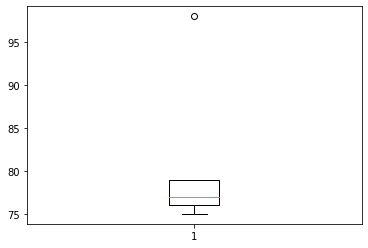

In [76]:
plt.boxplot(y1)

- A반의 boxplot
- 뚝 떨어진 하나의 점은 98점 
- 붉은 선은 중앙값 (평균이 아니라 중앙값) 
- 나머지 점들은 7~80점에 분포되어있다. 

{'whiskers': [<matplotlib.lines.Line2D at 0x7f6386868bb0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f638687b310>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f6386868820>],
 'medians': [<matplotlib.lines.Line2D at 0x7f638687ba30>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f638687bdc0>],
 'means': []}

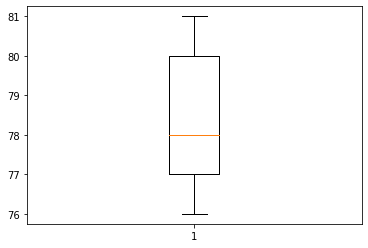

In [12]:
plt.boxplot(y2)

- B반의 boxplot

`-` 따로따로 그리는것은 별로 좋지않은 시각화 방법같다. (한눈에 보이지 않음, y축의 scale도 다름)

`-` 아래와 같이 개선해보자. 

{'whiskers': [<matplotlib.lines.Line2D at 0x7f638685ca60>,
 'caps': [<matplotlib.lines.Line2D at 0x7f63867eb1c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f638685c6d0>,
 'medians': [<matplotlib.lines.Line2D at 0x7f63867eb8e0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7f63867ebc70>,
 'means': []}

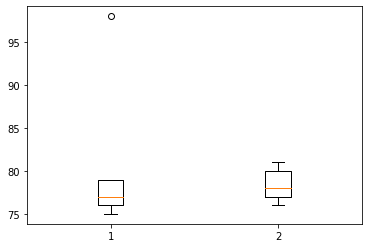

In [13]:
plt.boxplot([y1,y2])

`-` 미적인 요소가 아쉽긴 하지만 이정도는 괜찮다. 

#### 박스플랏이란? (통계학과)

`-` ref: https://towardsdatascience.com/understanding-boxplots-5e2df7bcbd51
 - github: https://github.com/mGalarnyk/Python_Tutorials/blob/master/Statistics/boxplot/box_plot.ipynb

`-` 아래의 그림을 보면서 이해하자. 

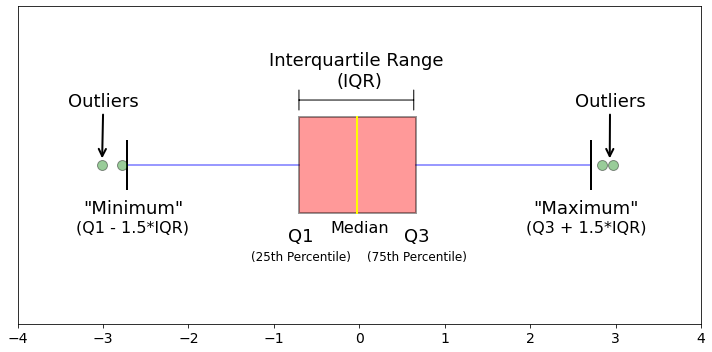

In [56]:
#collapse
np.random.seed(916170)

# connection path is here: https://stackoverflow.com/questions/6146290/plotting-a-line-over-several-graphs
mu, sigma = 0, 1 # mean and standard deviation
s = np.random.normal(mu, sigma, 1000)

fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize=(10, 5))

# rectangular box plot
bplot = axes.boxplot(s,
                vert=False,
                patch_artist=True, 
                showfliers=True, # This would show outliers (the remaining .7% of the data)
                positions = [0],
                boxprops = dict(linestyle='--', linewidth=2, color='Black', facecolor = 'red', alpha = .4),
                medianprops = dict(linestyle='-', linewidth=2, color='Yellow'),
                whiskerprops = dict(linestyle='-', linewidth=2, color='Blue', alpha = .4),
                capprops = dict(linestyle='-', linewidth=2, color='Black'),
                flierprops = dict(marker='o', markerfacecolor='green', markersize=10,
                  linestyle='none', alpha = .4),
                widths = .3,
                zorder = 1)   

axes.set_xlim(-4, 4)
plt.xticks(fontsize = 14)

axes.set_yticks([])
axes.annotate(r'',
            xy=(-.73, .205), xycoords='data',
            xytext=(.66, .205), textcoords='data',
            arrowprops=dict(arrowstyle="|-|",
                            connectionstyle="arc3")
            );

axes.text(0, .25, "Interquartile Range \n(IQR)",  horizontalalignment='center', fontsize=18)
axes.text(0, -.21, r"Median", horizontalalignment='center', fontsize=16);
axes.text(2.65, -.15, "\"Maximum\"", horizontalalignment='center', fontsize=18);
axes.text(-2.65, -.15, "\"Minimum\"", horizontalalignment='center', fontsize=18);
axes.text(-.68, -.24, r"Q1", horizontalalignment='center', fontsize=18);
axes.text(-2.65, -.21, r"(Q1 - 1.5*IQR)", horizontalalignment='center', fontsize=16);
axes.text(.6745, -.24, r"Q3", horizontalalignment='center', fontsize=18);
axes.text(.6745, -.30, r"(75th Percentile)", horizontalalignment='center', fontsize=12);
axes.text(-.68, -.30, r"(25th Percentile)", horizontalalignment='center', fontsize=12);
axes.text(2.65, -.21, r"(Q3 + 1.5*IQR)", horizontalalignment='center', fontsize=16);

axes.annotate('Outliers', xy=(2.93,0.015), xytext=(2.52,0.20), fontsize = 18,
            arrowprops={'arrowstyle': '->', 'color': 'black', 'lw': 2},
            va='center');

axes.annotate('Outliers', xy=(-3.01,0.015), xytext=(-3.41,0.20), fontsize = 18,
            arrowprops={'arrowstyle': '->', 'color': 'black', 'lw': 2},
            va='center');

fig.tight_layout()

#### plotly (컴퓨터공학과)

In [48]:
import plotly.express as px
from IPython.display import HTML
import pandas as pd

In [58]:
A=pd.DataFrame({'y':y1,'x':['A']*len(y1)})
B=pd.DataFrame({'y':y2,'x':['B']*len(y2)})
df=pd.concat([A,B],ignore_index=True)

In [59]:
df

,y,x
0,75,A
1,75,A
2,76,A
3,76,A
4,77,A
5,77,A
6,79,A
7,79,A
8,79,A
9,98,A


In [60]:
fig=px.box(data_frame=df,x='x',y='y')
HTML(fig.to_html(include_plotlyjs='cdn',include_mathjax=False))

### histogram

#### 히스토그램이란? 

`-` X축이 변수의 구간, Y축은 그 구간에 포함된 빈도를 의미함 

`-` 예를들면 아래와 같은것 

(array([  10.,   90.,  503., 1534., 2727., 2789., 1662.,  548.,  118.,
          19.]),
 array([-3.79519698, -3.04327907, -2.29136117, -1.53944326, -0.78752536,
        -0.03560745,  0.71631045,  1.46822836,  2.22014626,  2.97206416,
         3.72398207]),
 <BarContainer object of 10 artists>)

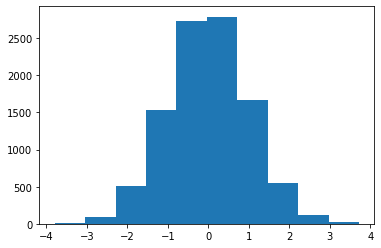

In [83]:
plt.hist(np.random.normal(loc=0,scale=1,size=10000))

#### 전북고예제

`-` 중심경향값, 집중경항치 (Measure of central tendency): 분포의 중심성을 나타내기 위한 값, 예시로는 평균 중앙값등이 있음. 
- https://en.wikipedia.org/wiki/Central_tendency

`-` "평균이 항상 좋은 중심경향값은 아니다"라는 사실은 이해했음. 

`-` 하지만 특수한 상황을 가정하면 평균이 좋은 중심경향값임. 

In [98]:
np.random.seed(43052)
y1=np.random.normal(loc=0,scale=1,size=10000) # 전북고 A반의 통계학 성적이라 생각하자. 
y2=np.random.normal(loc=0.5,scale=1,size=10000) # 전북고 B반의 통계학 성적이라 생각하자. 

In [99]:
np.mean(y1), np.mean(y2)

(-0.011790879905079434, 0.4979147460611458)

In [100]:
(np.mean(y2)-np.mean(y1)).round(3)

0.51

{'whiskers': [<matplotlib.lines.Line2D at 0x7f6375dcd700>,
 'caps': [<matplotlib.lines.Line2D at 0x7f6375dcde50>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f6375dcd4c0>,
 'medians': [<matplotlib.lines.Line2D at 0x7f6375ddb5b0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7f6375ddb940>,
 'means': []}

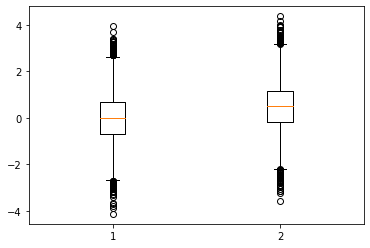

In [101]:
plt.boxplot([y1,y2])

- 분포의 모양은 거의 비슷하다. 

- 이런상황에서는 $B반의 성적 \approx A반의 성적+0.51$ 라고 주장해도 큰 무리가 없을 정도 

`-` 정규분포를 가정하면 앞선예제와 같은 모양이 잘 안나옴. 

`-` 그런데 정규분포인것은 어떻게 아는가? $\to$ 히스토그램을 그려봐서 종모양이 나오는지 살펴보자. 

(array([  1.,   1.,   3.,   0.,   1.,   4.,   5.,  12.,  14.,  26.,  32.,
         52.,  67.,  89., 144., 171., 238., 282., 325., 378., 489., 492.,
        561., 635., 652., 636., 626., 606., 573., 539., 475., 444., 350.,
        250., 232., 172., 137.,  80.,  58.,  47.,  30.,  23.,  17.,  12.,
          9.,   4.,   4.,   0.,   1.,   1.]),
 array([-4.12186916, -3.96068404, -3.79949892, -3.6383138 , -3.47712868,
        -3.31594356, -3.15475844, -2.99357332, -2.8323882 , -2.67120308,
        -2.51001796, -2.34883284, -2.18764772, -2.0264626 , -1.86527748,
        -1.70409236, -1.54290724, -1.38172212, -1.220537  , -1.05935188,
        -0.89816676, -0.73698164, -0.57579652, -0.4146114 , -0.25342628,
        -0.09224116,  0.06894396,  0.23012908,  0.3913142 ,  0.55249932,
         0.71368444,  0.87486956,  1.03605468,  1.1972398 ,  1.35842492,
         1.51961004,  1.68079516,  1.84198028,  2.0031654 ,  2.16435052,
         2.32553564,  2.48672076,  2.64790588,  2.809091  ,  2.97027612,
 

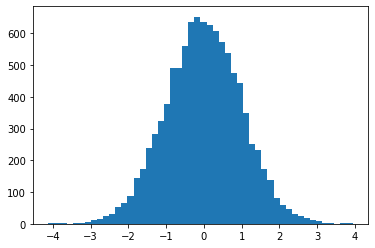

In [112]:
plt.hist(y1,bins=50)

(array([  1.,   0.,   3.,   2.,   4.,   5.,   5.,  10.,  16.,  25.,  33.,
         56.,  74., 116., 119., 152., 244., 272., 351., 362., 438., 509.,
        531., 621., 624., 690., 636., 571., 564., 514., 462., 402., 356.,
        297., 233., 184., 144., 113.,  80.,  55.,  38.,  34.,  21.,  18.,
          4.,   3.,   2.,   4.,   1.,   1.]),
 array([-3.5752867 , -3.4164866 , -3.2576865 , -3.0988864 , -2.9400863 ,
        -2.7812862 , -2.6224861 , -2.463686  , -2.3048859 , -2.1460858 ,
        -1.9872857 , -1.8284856 , -1.6696855 , -1.5108854 , -1.3520853 ,
        -1.1932852 , -1.0344851 , -0.875685  , -0.7168849 , -0.5580848 ,
        -0.3992847 , -0.2404846 , -0.0816845 ,  0.0771156 ,  0.2359157 ,
         0.3947158 ,  0.5535159 ,  0.712316  ,  0.87111611,  1.02991621,
         1.18871631,  1.34751641,  1.50631651,  1.66511661,  1.82391671,
         1.98271681,  2.14151691,  2.30031701,  2.45911711,  2.61791721,
         2.77671731,  2.93551741,  3.09431751,  3.25311761,  3.41191771,
 

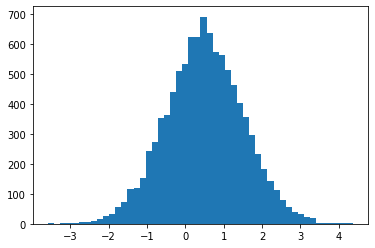

In [113]:
plt.hist(y2,bins=50)

(array([[  1.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   1.,   1.,   1.,
           0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   1.,   1.,   2.,
           1.,   0.,   1.,   1.,   3.,   4.,   4.,   2.,   2.,   6.,   4.,
           1.,   4.,   7.,   8.,   9.,  11.,   5.,   9.,   9.,  14.,  12.,
          16.,  11.,   9.,  18.,  25.,  30.,  22.,  18.,  28.,  29.,  39.,
          40.,  41.,  37.,  42.,  48.,  56.,  58.,  49.,  80.,  62.,  62.,
          91.,  78.,  75.,  82.,  89.,  81., 106.,  85.,  89., 126., 125.,
         106., 142., 141., 121., 121., 135., 154., 166., 146., 125., 169.,
         160., 170., 172., 162., 161., 161., 193., 146., 186., 170., 166.,
         197., 152., 149., 167., 173., 158., 155., 156., 153., 152., 137.,
         151., 147., 126., 141., 125., 139., 117., 116., 135., 118.,  93.,
         115.,  99.,  78.,  91.,  77.,  63.,  81.,  52.,  83.,  53.,  61.,
          49.,  46.,  46.,  47.,  45.,  26.,  48.,  31.,  27.,  27.,  20.,
          17.,  22.,  15.

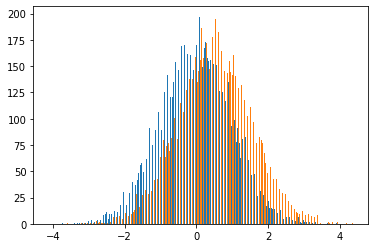

In [183]:
plt.hist([y1,y2],bins=200)

#### seaborn

In [373]:
A=pd.DataFrame({'y':y1,'x':['A']*len(y1)})
B=pd.DataFrame({'y':y2,'x':['B']*len(y2)})
df=pd.concat([A,B],ignore_index=True)

<AxesSubplot:xlabel='y', ylabel='Count'>

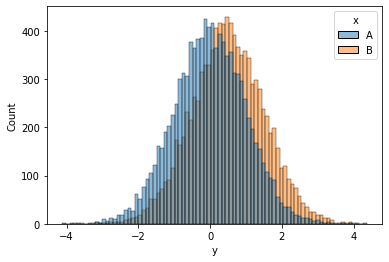

In [374]:
sns.histplot(df,x='y',hue='x')

#### plotnine

/home/cgb4/anaconda3/envs/py38r40/lib/python3.8/site-packages/plotnine/stats/stat_bin.py:95: PlotnineWarning: 'stat_bin()' using 'bins = 84'. Pick better value with 'binwidth'.


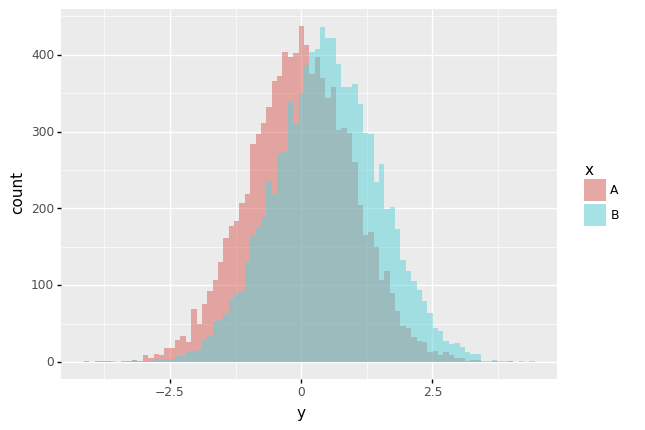

<ggplot: (8753717826934)>

In [375]:
from plotnine import *
ggplot(df)+geom_histogram(aes(x='y',fill='x'),position='identity',alpha=0.5)

#### plotly

`-` 인터렉티브 그래프를 위하여 plotly 갤러리 구경 

In [376]:
import plotly.figure_factory as ff
fig = ff.create_distplot([y1,y2], ['A','B'])
HTML(fig.to_html(include_plotlyjs='cdn',include_mathjax=False))

`-` bin_size 변경

In [377]:
fig = ff.create_distplot([y1,y2], ['A','B'], bin_size=.1)
HTML(fig.to_html(include_plotlyjs='cdn',include_mathjax=False))

`-` 밑에 분포그램 없애기

In [378]:
fig = ff.create_distplot([y1,y2], ['A','B'], bin_size=.1,show_rug=False)
HTML(fig.to_html(include_plotlyjs='cdn',include_mathjax=False))

#### HE, Histogram Equalization

`-` ref: https://docs.opencv.org/4.5.0/d5/daf/tutorial_py_histogram_equalization.html

In [294]:
#!pip install opencv-python
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
img = cv.imread('2021-09-05-Unequalized_Hawkes_Bay_NZ.jpeg',0)

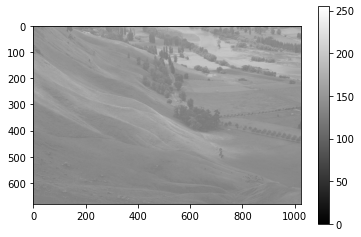

In [390]:
plt.imshow(img,cmap='gray',vmin=0,vmax=255)
plt.colorbar()

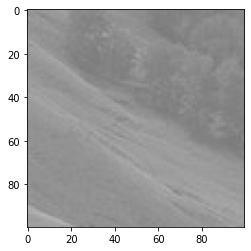

In [384]:
plt.imshow(img[200:300,400:500],cmap='gray',vmin=0,vmax=255)

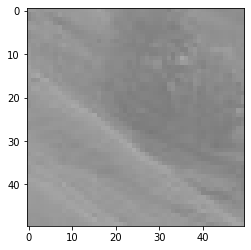

In [383]:
plt.imshow(img[200:250,400:450],cmap='gray',vmin=0,vmax=255)

In [382]:
df=pd.DataFrame(img)
df.iloc[200:250,400:450].style.set_properties(**{'font-size':'10pt'}).background_gradient('gray',vmin=0,vmax=255)

,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449
200,155,155,151,149,152,152,151,152,152,152,152,153,154,155,157,158,164,157,150,148,146,143,139,138,138,140,142,140,138,137,137,137,131,142,147,143,143,150,153,151,149,148,146,143,141,141,142,143,143,143
201,139,148,152,149,145,142,147,156,150,152,154,154,153,153,155,157,158,159,155,149,144,142,139,136,138,139,140,139,137,136,136,137,141,140,139,141,147,152,152,150,151,150,149,147,145,143,143,143,141,142
202,138,145,149,149,149,144,138,139,144,148,153,155,153,152,153,155,153,158,157,147,140,140,139,136,137,135,135,137,137,135,134,136,142,138,139,145,147,144,145,151,150,150,151,150,149,147,145,143,140,140
203,152,151,148,150,156,152,141,134,137,141,147,151,152,152,153,154,152,155,153,144,137,138,139,139,134,130,130,134,135,133,133,136,133,132,137,146,147,141,141,147,146,147,148,149,150,149,147,145,143,142
204,155,156,153,151,153,153,152,155,141,141,142,144,147,149,151,151,153,152,149,145,140,137,138,140,133,130,129,131,132,131,132,134,130,127,130,139,147,147,144,141,144,144,144,146,147,147,147,146,147,146
205,145,151,152,153,154,152,152,156,151,147,141,139,141,144,147,148,151,149,149,148,145,138,135,136,134,133,131,130,130,130,131,132,134,133,134,136,139,142,143,143,145,144,142,143,144,145,144,144,146,146
206,143,147,149,151,155,152,146,145,154,151,146,143,142,143,144,145,144,146,147,146,142,138,136,134,133,135,134,130,129,132,134,134,135,136,137,136,133,135,142,150,147,145,143,143,144,145,144,143,145,145
207,148,151,150,149,151,150,149,151,150,150,151,150,148,145,144,144,137,144,145,139,135,137,138,135,131,136,136,130,129,135,138,137,134,129,128,132,137,140,146,153,147,145,144,144,145,146,145,143,147,147
208,150,148,151,145,143,147,148,153,158,153,150,152,149,143,141,144,145,145,144,142,140,137,133,131,130,133,131,130,137,143,140,135,141,139,130,134,147,142,135,144,147,143,146,148,144,146,149,144,148,144
209,153,147,147,143,144,147,144,146,150,149,150,152,153,151,146,143,142,142,141,139,137,135,134,134,133,131,130,129,130,132,134,133,136,139,137,130,132,146,151,142,145,146,153,156,154,156,156,149,145,148


Text(0.5, 1.0, 'before HE')

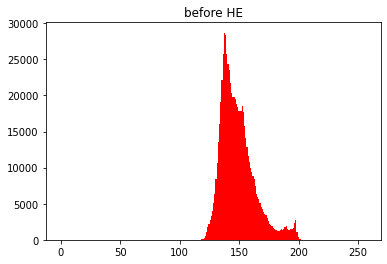

In [385]:
plt.hist(img.flatten(),256,[0,256],color='r')
plt.title('before HE')

In [398]:
img2=cv.equalizeHist(img)

In [400]:
df=pd.DataFrame(img2)
df.iloc[200:250,400:450].style.set_properties(**{'font-size':'10pt'}).background_gradient('gray',vmin=0,vmax=255)

,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449
200,194,194,170,157,177,177,170,177,177,177,177,183,189,194,203,207,225,203,163,150,137,115,82,73,73,91,108,91,73,63,63,63,17,108,144,115,115,163,183,170,157,150,137,115,100,100,108,115,115,115
201,82,150,177,157,130,108,144,199,163,177,189,189,183,183,194,203,207,210,194,157,122,108,82,52,73,82,91,82,63,52,52,63,100,91,82,100,144,177,177,163,170,163,157,144,130,115,115,115,100,108
202,73,130,157,157,157,122,73,82,122,150,183,194,183,177,183,194,183,207,203,144,91,91,82,52,63,43,43,63,63,43,35,52,108,73,82,130,144,122,130,170,163,163,170,163,157,144,130,115,91,91
203,177,170,150,163,199,177,100,35,63,100,144,170,177,177,183,189,177,194,183,122,63,73,82,82,35,13,13,35,43,28,28,52,28,22,63,137,144,100,100,144,137,144,150,157,163,157,144,130,115,108
204,194,199,183,170,183,183,177,194,100,100,108,122,144,157,170,170,183,177,157,130,91,63,73,91,28,13,10,17,22,17,22,35,13,6,13,82,144,144,122,100,122,122,122,137,144,144,144,137,144,137
205,130,170,177,183,189,177,177,199,170,144,100,82,100,122,144,150,170,157,157,150,130,73,43,52,35,28,17,13,13,13,17,22,35,28,35,52,82,108,115,115,130,122,108,115,122,130,122,122,137,137
206,115,144,157,170,194,177,137,130,189,170,137,115,108,115,122,130,122,137,144,137,108,73,52,35,28,43,35,13,10,22,35,35,43,52,63,52,28,43,108,163,144,130,115,115,122,130,122,115,130,130
207,150,170,163,157,170,163,157,170,163,163,170,163,150,130,122,122,63,122,130,82,43,63,73,43,17,52,52,13,10,43,73,63,35,10,8,22,63,91,137,183,144,130,122,122,130,137,130,115,144,144
208,163,150,170,130,115,144,150,183,207,183,163,177,157,115,100,122,130,130,122,108,91,63,28,17,13,28,17,13,63,115,91,43,100,82,13,35,144,108,43,122,144,115,137,150,122,137,157,122,150,122
209,183,144,144,115,122,144,122,137,163,157,163,177,183,170,137,115,108,108,100,82,63,43,35,35,28,17,13,10,13,22,35,28,52,82,63,13,22,137,170,108,130,137,183,199,189,199,199,157,130,150


Text(0.5, 1.0, 'after HE')

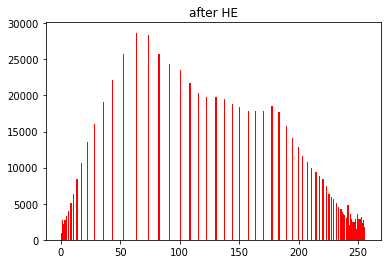

In [401]:
plt.hist(img2.flatten(),256,[0,256],color='r')
plt.title('after HE')

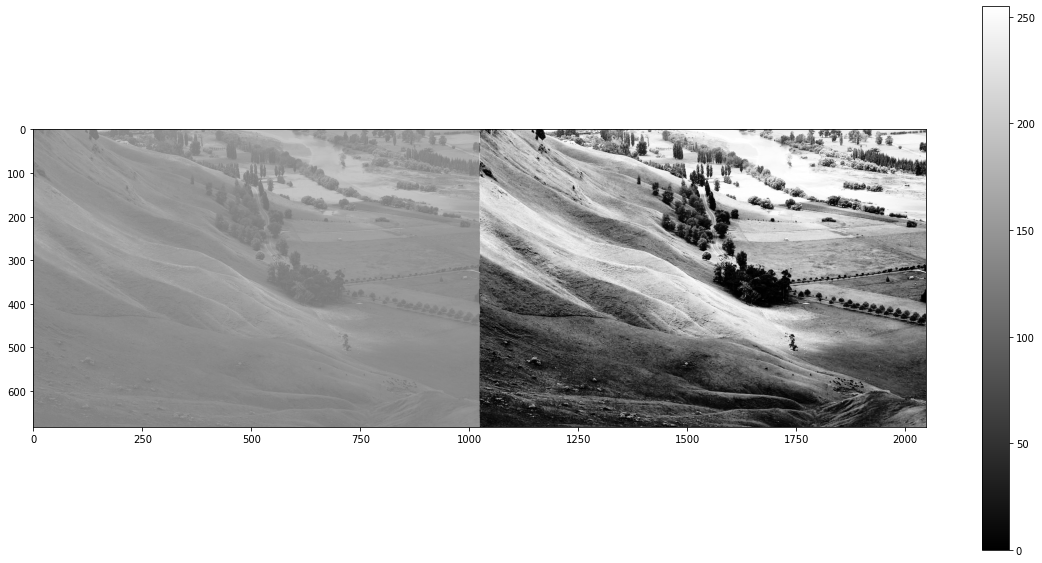

In [402]:
_img=np.hstack((img,img2)) #stacking image side by side 
fig=plt.figure(figsize=(20,10))
plt.imshow(_img,cmap='gray')
plt.colorbar()